# Exercise 1: Summing lists and arrays

Python's built-in function
[`sum()`](https://docs.python.org/3/library/functions.html#sum)
and NumPy's function
[`np.sum()`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)
can both be used to sum sequences of numbers.
In this exercise, we compare the execution time of `sum()` and `np.sum()`
for sequences of different lengths.

1. Create a list `lst` and a NumPy array `arr`, each of them containing the sequence 
   of ten values `0, 1, 2, ..., 9`.

   *Hint*: You can use the list constructor 
   [`list()`](https://docs.python.org/3/library/functions.html#func-list)
   and combine it with the 
   [`range()`](https://docs.python.org/3/library/functions.html#func-range)
   function, which returns an object representing a range of integers.

   *Hint*: You should create the NumPy array using 
   [`np.arange()`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html).

2. We want to compute the sum of integers contained in `lst` and `arr`. Use 
   the built-in function 
   [`sum()`](https://docs.python.org/3/library/functions.html#sum)
   to sum elements of a list.
   For the NumPy array, use the NumPy function 
   [`np.sum()`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html).

3. You are interested in benchmarking which summing function is faster.
   Repeat the steps from above, but use the cell magic 
   [`%timeit`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit)
   to time the execution of a statement as follows:

    ```python
    %timeit statement
    ```

4.  Recreate the list and array to contain 100 integers starting from 0,
    and rerun the benchmark.

5.  Recreate the list and array to contain 10,000 integers starting from 0,
    and rerun the benchmark.


What do you conclude about the relative performance of built-in lists 
vs. NumPy arrays?

In [6]:
import numpy as np
#since we are calling a functiin we use the regular brackets and not square brackets.
lst = (range(10))
arr=np.arange(10)

%timeit np.sum(arr)
%timeit sum(lst)





2.37 μs ± 267 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


KeyboardInterrupt: 

***
# Exercise 2: Maximizing quadratic utility

In economics, we usually represent an individual's preferences with a utility
function, $u(\bullet)$.
Assume that utility from consuming $c$ units is given by the following
quadratic function:
$$
u(c) = - A (c - B)^2 + C
$$

where $A > 0$, $B > 0$, and $C$ are parameters, and $c$ is the consumption
level.
The following code plots the function for specific parameter values. We will
cover plotting in detail in later weeks, so you can ignore the code for now:

Text(0, 0.5, 'Utility')

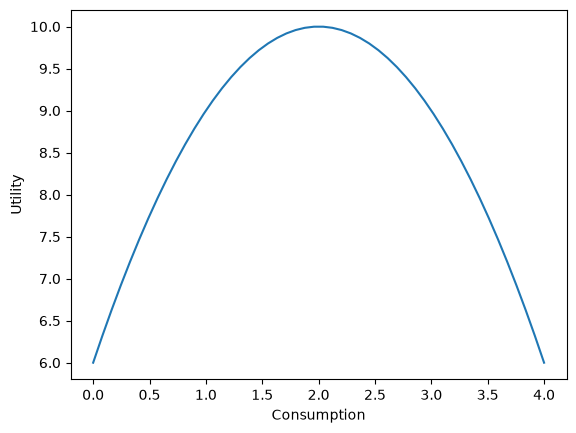

In [7]:
import matplotlib.pyplot as plt

c = np.linspace(0, 4, 50)
u = -1 * (c - 2) ** 2 + 10
plt.plot(c, u)
plt.xlabel('Consumption')
plt.ylabel('Utility')

In this exercise, you are asked to locate the consumption level that yields
the maximum utility.

1. Define a function `util()` that takes the consumption level `c` and three
   additional arguments, `A`, `B`, and `C`. These are the parameters of
   $u(\bullet)$ defined above. The function should return the utility associated
   with the consumption level `c`.

   *Hint*: Use the `**` operator for exponentiation in Python. For example,
   `x ** 2` computes the square of `x`.

2. Write a function `find_max_cons()` that takes a sequence of candidate
   consumption levels and the three parameters `A`, `B`, and `C`. The function
   should return the maximum utility and the corresponding consumption level.
   The function definition should look like this:
   ```python
   def find_max_cons(candidates, A, B, C):
       """
       Find the consumption level that maximizes utility from a
       sequence of candidates.

       Parameters
       ----------
       candidates : list or array-like
           Sequence of candidate consumption levels to evaluate.
       A, B, C : float
           Parameters of the utility function.

       Returns
       -------
       u_max
           Maximized utility
       cons_max
           Consumption at which utility is maximized
       """
   ```

   Your algorithm should perform the following steps:

   1. Initialize `u_max` to `-np.inf` (negative infinity).
   2. Loop through all candidate consumption levels and compute the associated
      utility. If this utility is larger than the current maximum value
      `u_max`, update `u_max` and store the associated consumption level
      `cons_max`.
   3. Return `u_max` and `cons_max` after the loop terminates.

3. Find the maximum:
   1. Create an array `cons` containing 51 uniformly spaced candidate
      consumption levels on the interval $[0, 4]$.

      *Hint*: Use
[`np.linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
      for this task.

   2. Use the parameters $A = 1$, $B = 2$, and $C = 10$.
   3. Use `find_max_cons()` to compute the maximum utility and the corresponding
      optimal consumption level, and print the results.

4. Repeat the exercise using vectorized NumPy operations:
   1. Compute and store the utility levels for *all* elements in `cons` at once
      by applying the formula to the entire array.
   2. Locate the index of the maximum utility level using
[`np.argmax()`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html).
   3. Use the index returned by `np.argmax()` to retrieve the maximum utility
      and the corresponding consumption level, and print the results.

In [ ]:
import numpy as np

# We define the function of the variabels c0 CONSUMPTION, and the others are regular variabels. 
def util(c, A, B, C):
    #this actually calculates the function for different values of variabels. Note that all variabels are included. 
    return -A * (c - B) ** 2 + C
#Here we call the function and calculate it for the given variabels and print the result.
print(util(2, 1, 2, 10))

#We define a new function, which role is to compare different utility levels
cons = np.linspace(0,4,51)
def find_max_cons(candidates,A,B,C):
    #We start u_max at - infinity to ensure the fist utility level beats it. 
    u_max = -np.inf
    #cons_max will store the utility level that gives the best consumption level. none means we have not found any yet. 
    cons_max = None

    #This starts a new loop, where c changes and A,B,C are kept fixed.
    for c in candidates:
        #We store the result in u
        u=util(c,A,B,C)
        if u > u_max:
            u_max = u # Stores the consumption level that gives 
            cons_max = c #stores the consumption level that gives highest utility
    return u_max, cons_max
#The [0,1,2] inside the function call just means that we check a number of variabels for c, whilst keeping the other constant. 
#here we call the function that finds max consumption and print result
print(find_max_cons(cons,1,2,10))
#Here we call the utility function and print it. this gives 1 answer as it goes through the sorting loop.
#This gives multiple answers as it prints for all values in the array.
print(util(cons, 1,2,10))

#We call the util function once more, this here returns all values in cons array for function.
utilities =  util(cons,1,2,10)
#We then find the index that maximizes the function. since the others are given as constants we find the value of cons that gives largest function, we find this index. 
best_index = np.argmax(utilities)

#Here we take the best consupmtion level we found for the utility function and print it.
print(utilities[best_index]) 
#Here we print the consumption level at the best index.
print(cons[best_index])       





            
        




10
(np.float64(10.0), np.float64(2.0))
[ 6.      6.3136  6.6144  6.9024  7.1776  7.44    7.6896  7.9264  8.1504
  8.3616  8.56    8.7456  8.9184  9.0784  9.2256  9.36    9.4816  9.5904
  9.6864  9.7696  9.84    9.8976  9.9424  9.9744  9.9936 10.      9.9936
  9.9744  9.9424  9.8976  9.84    9.7696  9.6864  9.5904  9.4816  9.36
  9.2256  9.0784  8.9184  8.7456  8.56    8.3616  8.1504  7.9264  7.6896
  7.44    7.1776  6.9024  6.6144  6.3136  6.    ]
10.0
2.0


***
# Exercise 3: Progressive income taxation

Consider the following simplified, illustrative progressive income-tax
system:

- Income up to NOK 300,000 is not taxed.
- Income from NOK 300,000 to NOK 700,000 is taxed at 20%.
- Income above NOK 700,000 is taxed at 35%.

This schedule is designed for the exercise and does not represent the actual
Norwegian tax system.

1. Define a function `tax()` that takes annual income in NOK as its argument
   and returns the amount of tax owed. Use `if`, `elif`, and `else` to handle
   the three income ranges.

2. Calculate taxes for a sequence of incomes using a loop:

   1. Create an array `incomes` containing 13 evenly spaced values from
      NOK 0 to NOK 1,200,000 using
[`np.linspace()`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html).
   2. Create an empty array `taxes_loop` with the same shape as `incomes`.
   3. Loop over `incomes`, evaluate `tax()` for each element, and store the
      result in `taxes_loop`.
   4. Compute the corresponding after-tax incomes.
   5. Print a table with one row per income and columns for gross income,
      tax, and after-tax income. Report all amounts in NOK.

3. Define a function `tax_numpy()` that takes an array of annual incomes and
   returns an array containing the corresponding taxes. The function should
   use vectorized NumPy operations instead of a loop. 
   
   *Hint:* Use
   [`np.maximum()`](https://numpy.org/doc/stable/reference/generated/numpy.maximum.html)
   to prevent taxable amounts from becoming negative and
   [`np.minimum()`](https://numpy.org/doc/stable/reference/generated/numpy.minimum.html)
   to cap the income taxed at 20% at NOK 400,000.

   Call `tax_numpy()` with `incomes` and compute the corresponding after-tax
   incomes. Use
[`np.allclose()`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html)
   to verify that the loop and vectorized calculations produce the same
   taxes and after-tax incomes.

In [ ]:
import numpy as np

def 